In [31]:
import json
from pathlib import Path
from itertools import product
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath("../"))
from simulators.drossel_schwabl_CA import DrosselSchwablForestFire
from simulators.CA_modified import CellularAutomaton_humidity_age
from simulators.metrics import FireMetrics

In [32]:
DATASET_DIR = Path("synthetic_fire_dataset")

env = np.load(DATASET_DIR / "common_maps.npz")
height_grid = env["height_grid"]
age_grid = env["age_grid"]
moisture_grid = env["moisture_grid"]

with open(DATASET_DIR / "dataset_index.json", "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

print("Nombre de feux :", len(dataset_index))
print("Shape :", height_grid.shape)

with open(DATASET_DIR / "config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

N_STEPS = config["N_STEPS"]
print("N_STEPS used for evaluation:", N_STEPS)

Nombre de feux : 20
Shape : (100, 100)
N_STEPS used for evaluation: 20


In [33]:
def make_phi(gamma):
    def phi(delta_h):
        if delta_h <= 0:
            return np.exp(gamma * delta_h)
        else:
            return 1.0 + gamma * np.sqrt(delta_h)
    return phi

def make_psi(beta):
    def psi(m):
        return np.exp(-beta * m)
    return psi

In [42]:
def initialize_single_ignition(ca, ignition_point, value=0.8):
    i0, j0 = int(ignition_point[0]), int(ignition_point[1])
    ca.initialize_ignition([(i0, j0)], [value])

In [49]:
def simulate_fire_candidate(
    height_grid,
    age_grid,
    moisture_grid,
    wind_grid,
    ignition_point,
    alpha,
    beta,
    gamma,
    n_steps=N_STEPS,
):
    H, W = height_grid.shape

    ca = CellularAutomaton_humidity_age(
        grid_height=H,
        grid_width=W,
        wind_grid=wind_grid,
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        phi=make_phi(gamma),
        psi=make_psi(beta),
        alpha_age=alpha,
    )

    initialize_single_ignition(ca, ignition_point, value=0.8)

    arrival_time = -np.ones((H, W), dtype=np.int16)
    state0 = ca.get_state().copy()
    arrival_time[state0 >= 0.5] = 0

    for step in range(n_steps):
        ca.evolve(use_age=True, use_moisture=True)

        state = ca.get_state().copy()
        new_cells = (state >= 0.5) & (arrival_time < 0)
        arrival_time[new_cells] = step + 1

    return {
        "final_state": ca.get_state().copy().astype(np.float32),
        "arrival_time": arrival_time,
    }

In [50]:
def iou_score(pred, obs, tau=0.5):
    pred_bin = pred >= tau
    obs_bin = obs >= tau

    inter = np.logical_and(pred_bin, obs_bin).sum()
    union = np.logical_or(pred_bin, obs_bin).sum()

    if union == 0:
        return 1.0
    return inter / union

In [51]:
def evaluate_one_fire_metrics(
    fire_path,
    height_grid,
    age_grid,
    moisture_grid,
    alpha,
    beta,
    gamma,
    n_steps=N_STEPS,
    tau=0.5,
):
    obs = np.load(fire_path)

    wind_grid = obs["wind_grid"].astype(np.float32)
    ignition_point = obs["ignition_point"].astype(np.int16)
    obs_final = obs["final_state"].astype(np.float32) / 255.0
    obs_arrival = obs["arrival_time"].astype(np.int16)

    pred = simulate_fire_candidate(
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        wind_grid=wind_grid,
        ignition_point=ignition_point,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        n_steps=n_steps,
    )

    pred_final = pred["final_state"]
    pred_arrival = pred["arrival_time"]

    iou = iou_score(pred_final, obs_final, tau=tau)
    aatd = FireMetrics.aatd_from_maps(pred_arrival, obs_arrival)

    return {
        "iou": float(iou),
        "iou_loss": float(1.0 - iou),
        "aatd": float(aatd) if np.isfinite(aatd) else np.nan,
    }

In [52]:
def evaluate_params_metrics(
    fire_paths,
    height_grid,
    age_grid,
    moisture_grid,
    alpha,
    beta,
    gamma,
    n_steps=N_STEPS,
    tau=0.5,
):
    scores = []

    for fire_path in fire_paths:
        s = evaluate_one_fire_metrics(
            fire_path=fire_path,
            height_grid=height_grid,
            age_grid=age_grid,
            moisture_grid=moisture_grid,
            alpha=alpha,
            beta=beta,
            gamma=gamma,
            n_steps=n_steps,
            tau=tau,
        )
        scores.append(s)

    mean_iou = float(np.mean([s["iou"] for s in scores]))
    mean_iou_loss = float(np.mean([s["iou_loss"] for s in scores]))

    valid_aatd = [s["aatd"] for s in scores if np.isfinite(s["aatd"])]
    mean_aatd = float(np.mean(valid_aatd)) if len(valid_aatd) > 0 else np.nan

    return {
        "alpha": alpha,
        "beta": beta,
        "gamma": gamma,
        "mean_iou": mean_iou,
        "mean_iou_loss": mean_iou_loss,
        "mean_aatd": mean_aatd,
    }

In [53]:
alpha_grid = [0.8, 2.0, 4.0]
beta_grid  = [0.5, 2.0, 5.0]
gamma_grid = [0.4, 1.2, 3.0]

N_EVAL_FIRES = 10

fire_paths = [
    DATASET_DIR / item["file"]
    for item in dataset_index[:N_EVAL_FIRES]
]

print("Nombre de triplets testés :", len(alpha_grid) * len(beta_grid) * len(gamma_grid))
print("Nombre de feux utilisés :", len(fire_paths))

Nombre de triplets testés : 27
Nombre de feux utilisés : 10


In [54]:
results = []

for alpha, beta, gamma in product(alpha_grid, beta_grid, gamma_grid):
    print(f"Test alpha={alpha}, beta={beta}, gamma={gamma}")

    row = evaluate_params_metrics(
        fire_paths=fire_paths,
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        n_steps=N_STEPS,
        tau=0.5,
    )

    results.append(row)

results_df = pd.DataFrame(results)

Test alpha=0.8, beta=0.5, gamma=0.4
Test alpha=0.8, beta=0.5, gamma=1.2
Test alpha=0.8, beta=0.5, gamma=3.0
Test alpha=0.8, beta=2.0, gamma=0.4
Test alpha=0.8, beta=2.0, gamma=1.2
Test alpha=0.8, beta=2.0, gamma=3.0
Test alpha=0.8, beta=5.0, gamma=0.4
Test alpha=0.8, beta=5.0, gamma=1.2
Test alpha=0.8, beta=5.0, gamma=3.0
Test alpha=2.0, beta=0.5, gamma=0.4
Test alpha=2.0, beta=0.5, gamma=1.2
Test alpha=2.0, beta=0.5, gamma=3.0
Test alpha=2.0, beta=2.0, gamma=0.4
Test alpha=2.0, beta=2.0, gamma=1.2
Test alpha=2.0, beta=2.0, gamma=3.0
Test alpha=2.0, beta=5.0, gamma=0.4
Test alpha=2.0, beta=5.0, gamma=1.2
Test alpha=2.0, beta=5.0, gamma=3.0
Test alpha=4.0, beta=0.5, gamma=0.4
Test alpha=4.0, beta=0.5, gamma=1.2
Test alpha=4.0, beta=0.5, gamma=3.0
Test alpha=4.0, beta=2.0, gamma=0.4
Test alpha=4.0, beta=2.0, gamma=1.2
Test alpha=4.0, beta=2.0, gamma=3.0
Test alpha=4.0, beta=5.0, gamma=0.4
Test alpha=4.0, beta=5.0, gamma=1.2
Test alpha=4.0, beta=5.0, gamma=3.0


In [55]:
df = results_df.copy()
results_df.sort_values("mean_iou_loss").head(10)

best = results_df.sort_values("mean_iou_loss").iloc[0]

print("Meilleurs paramètres trouvés :")
print(best[["alpha", "beta", "gamma", "mean_iou", "mean_iou_loss"]])

Meilleurs paramètres trouvés :
alpha            2.0
beta             2.0
gamma            1.2
mean_iou         1.0
mean_iou_loss    0.0
Name: 13, dtype: float64


In [56]:
print(results_df.sort_values("mean_iou_loss"))

    alpha  beta  gamma  mean_iou  mean_iou_loss  mean_aatd
13    2.0   2.0    1.2  1.000000       0.000000   0.000000
12    2.0   2.0    0.4  0.969921       0.030079   0.189320
14    2.0   2.0    3.0  0.950278       0.049722   0.349988
3     0.8   2.0    0.4  0.872367       0.127633   1.034108
4     0.8   2.0    1.2  0.866511       0.133489   1.068840
5     0.8   2.0    3.0  0.836264       0.163736   1.358020
23    4.0   2.0    3.0  0.797435       0.202565   1.556012
22    4.0   2.0    1.2  0.784161       0.215839   1.614534
21    4.0   2.0    0.4  0.761678       0.238322   1.746046
18    4.0   0.5    0.4  0.734339       0.265661   1.785054
19    4.0   0.5    1.2  0.727446       0.272554   1.853394
20    4.0   0.5    3.0  0.715342       0.284658   1.948589
9     2.0   0.5    0.4  0.680715       0.319285   2.709205
10    2.0   0.5    1.2  0.676961       0.323039   2.770485
11    2.0   0.5    3.0  0.670223       0.329777   2.863373
0     0.8   0.5    0.4  0.656760       0.343240   3.2135

In [57]:
results_df.sort_values("mean_aatd").head(10)

,alpha,beta,gamma,mean_iou,mean_iou_loss,mean_aatd
13,2.0,2.0,1.2,1.000000,0.000000,0.000000
12,2.0,2.0,0.4,0.969921,0.030079,0.189320
14,2.0,2.0,3.0,0.950278,0.049722,0.349988
3,0.8,2.0,0.4,0.872367,0.127633,1.034108
4,0.8,2.0,1.2,0.866511,0.133489,1.068840
5,0.8,2.0,3.0,0.836264,0.163736,1.358020
23,4.0,2.0,3.0,0.797435,0.202565,1.556012
22,4.0,2.0,1.2,0.784161,0.215839,1.614534
21,4.0,2.0,0.4,0.761678,0.238322,1.746046
18,4.0,0.5,0.4,0.734339,0.265661,1.785054


## Test on the grund truth

In [59]:
def simulate_fire_candidate_with_trajectory(
    height_grid,
    age_grid,
    moisture_grid,
    wind_grid,
    ignition_point,
    alpha,
    beta,
    gamma,
    n_steps=N_STEPS,
    save_steps=None,
):
    H, W = height_grid.shape

    ca = CellularAutomaton_humidity_age(
        grid_height=H,
        grid_width=W,
        wind_grid=wind_grid,
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        phi=make_phi(gamma),
        psi=make_psi(beta),
        alpha_age=alpha,
    )

    initialize_single_ignition(ca, ignition_point, value=0.8)

    if save_steps is None:
        save_steps = [0, n_steps]
    save_steps = sorted(set(int(s) for s in save_steps))

    snapshots = {}
    arrival_time = -np.ones((H, W), dtype=np.int16)

    state = ca.get_state().copy()
    arrival_time[state >= 0.5] = 0

    if 0 in save_steps:
        snapshots[0] = state.copy().astype(np.float32)

    for step in range(1, n_steps + 1):
        ca.evolve(use_age=True, use_moisture=True)
        state = ca.get_state().copy()

        new_cells = (state >= 0.5) & (arrival_time < 0)
        arrival_time[new_cells] = step

        if step in save_steps:
            snapshots[step] = state.copy().astype(np.float32)

    return {
        "snapshots": snapshots,
        "final_state": ca.get_state().copy().astype(np.float32),
        "arrival_time": arrival_time,
    }

Best parameters found:
alpha = 2.0, beta = 2.0, gamma = 1.2
mean_iou = 1.0000


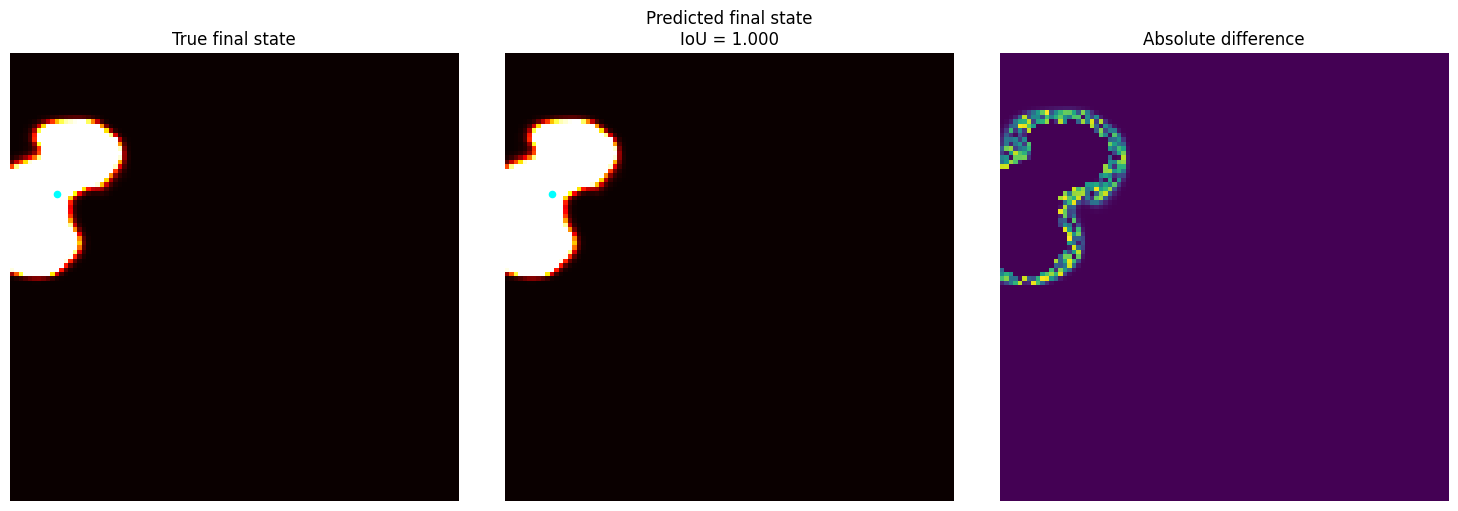

In [64]:
best = results_df.sort_values("mean_iou_loss").iloc[0]
best_alpha = float(best["alpha"])
best_beta = float(best["beta"])
best_gamma = float(best["gamma"])

print("Best parameters found:")
print(f"alpha = {best_alpha}, beta = {best_beta}, gamma = {best_gamma}")
print(f"mean_iou = {best['mean_iou']:.4f}")

fire_path = fire_paths[0]
obs = np.load(fire_path)

wind_grid = obs["wind_grid"].astype(np.float32)
ignition_point = obs["ignition_point"].astype(np.int16)
obs_final = obs["final_state"].astype(np.float32) / 255.0

pred = simulate_fire_candidate(
    height_grid=height_grid,
    age_grid=age_grid,
    moisture_grid=moisture_grid,
    wind_grid=wind_grid,
    ignition_point=ignition_point,
    alpha=best_alpha,
    beta=best_beta,
    gamma=best_gamma,
    n_steps=N_STEPS,
)

pred_final = pred["final_state"]

iou = iou_score(pred_final, obs_final, tau=0.5)

i0, j0 = int(ignition_point[0]), int(ignition_point[1])

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(obs_final, cmap="hot")
axs[0].scatter([j0], [i0], c="cyan", s=20)
axs[0].set_title("True final state")

axs[1].imshow(pred_final, cmap="hot")
axs[1].scatter([j0], [i0], c="cyan", s=20)
axs[1].set_title(f"Predicted final state\nIoU = {iou:.3f}")

diff = np.abs(pred_final - obs_final)
axs[2].imshow(diff, cmap="viridis")
axs[2].set_title("Absolute difference")

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [65]:
def plot_fire_comparison(
    fire_path,
    height_grid,
    age_grid,
    moisture_grid,
    alpha,
    beta,
    gamma,
    n_steps,
    step_indices=None,
):
    obs = np.load(fire_path)

    wind_grid = obs["wind_grid"].astype(np.float32)
    ignition_point = obs["ignition_point"].astype(np.int16)
    obs_saved_steps = obs["saved_steps"].astype(int)
    obs_snapshots = obs["snapshots"].astype(np.float32) / 255.0
    obs_final = obs["final_state"].astype(np.float32) / 255.0
    obs_arrival = obs["arrival_time"].astype(np.int16)

    if step_indices is None:
        idxs = np.unique(np.linspace(0, len(obs_saved_steps) - 1, 4, dtype=int))
    else:
        idxs = np.array(step_indices, dtype=int)

    selected_steps = obs_saved_steps[idxs].tolist()

    pred = simulate_fire_candidate_with_trajectory(
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        wind_grid=wind_grid,
        ignition_point=ignition_point,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        n_steps=n_steps,
        save_steps=selected_steps,
    )

    pred_snapshots = pred["snapshots"]
    pred_final = pred["final_state"]
    pred_arrival = pred["arrival_time"]

    i0, j0 = int(ignition_point[0]), int(ignition_point[1])

    n_time_cols = len(selected_steps)
    n_cols = n_time_cols + 2
    fig, axs = plt.subplots(3, n_cols, figsize=(3.3 * n_cols, 9))

    for c, (idx, step) in enumerate(zip(idxs, selected_steps)):
        axs[0, c].imshow(obs_snapshots[idx], cmap="hot")
        axs[0, c].scatter([j0], [i0], c="cyan", s=20)
        axs[0, c].set_title(f"GT t={step}")
        axs[0, c].axis("off")

    axs[0, n_time_cols].imshow(obs_final, cmap="hot")
    axs[0, n_time_cols].scatter([j0], [i0], c="cyan", s=20)
    axs[0, n_time_cols].set_title("GT final")
    axs[0, n_time_cols].axis("off")

    arr_gt_plot = np.where(obs_arrival >= 0, obs_arrival, np.nan)
    axs[0, n_time_cols + 1].imshow(arr_gt_plot, cmap="viridis")
    axs[0, n_time_cols + 1].scatter([j0], [i0], c="red", s=20)
    axs[0, n_time_cols + 1].set_title("GT arrival time")
    axs[0, n_time_cols + 1].axis("off")

    for c, step in enumerate(selected_steps):
        axs[1, c].imshow(pred_snapshots[step], cmap="hot")
        axs[1, c].scatter([j0], [i0], c="cyan", s=20)
        axs[1, c].set_title(f"Pred t={step}")
        axs[1, c].axis("off")

    axs[1, n_time_cols].imshow(pred_final, cmap="hot")
    axs[1, n_time_cols].scatter([j0], [i0], c="cyan", s=20)
    axs[1, n_time_cols].set_title("Pred final")
    axs[1, n_time_cols].axis("off")

    arr_pred_plot = np.where(pred_arrival >= 0, pred_arrival, np.nan)
    axs[1, n_time_cols + 1].imshow(arr_pred_plot, cmap="viridis")
    axs[1, n_time_cols + 1].scatter([j0], [i0], c="red", s=20)
    axs[1, n_time_cols + 1].set_title("Pred arrival time")
    axs[1, n_time_cols + 1].axis("off")

    for c, (idx, step) in enumerate(zip(idxs, selected_steps)):
        diff_t = np.abs(pred_snapshots[step] - obs_snapshots[idx])
        axs[2, c].imshow(diff_t, cmap="magma")
        axs[2, c].set_title(f"|Diff| t={step}")
        axs[2, c].axis("off")

    final_diff = np.abs(pred_final - obs_final)
    final_iou = iou_score(pred_final, obs_final, tau=0.5)

    axs[2, n_time_cols].imshow(final_diff, cmap="magma")
    axs[2, n_time_cols].set_title(f"|Diff| final\nIoU={final_iou:.3f}")
    axs[2, n_time_cols].axis("off")

    arrival_diff = np.full_like(pred_arrival, np.nan, dtype=float)
    valid = (pred_arrival >= 0) & (obs_arrival >= 0)
    arrival_diff[valid] = np.abs(pred_arrival[valid] - obs_arrival[valid])

    aatd_val = FireMetrics.aatd_from_maps(pred_arrival, obs_arrival)

    axs[2, n_time_cols + 1].imshow(arrival_diff, cmap="magma")
    axs[2, n_time_cols + 1].set_title(f"|Arrival diff|\nAATD={aatd_val:.3f}")
    axs[2, n_time_cols + 1].axis("off")

    plt.suptitle(
        f"{fire_path.name} | ignition={tuple(ignition_point.tolist())} | alpha={alpha}, beta={beta}, gamma={gamma}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

Best parameters according to AATD:
alpha        2.0
beta         2.0
gamma        1.2
mean_iou     1.0
mean_aatd    0.0
Name: 13, dtype: float64


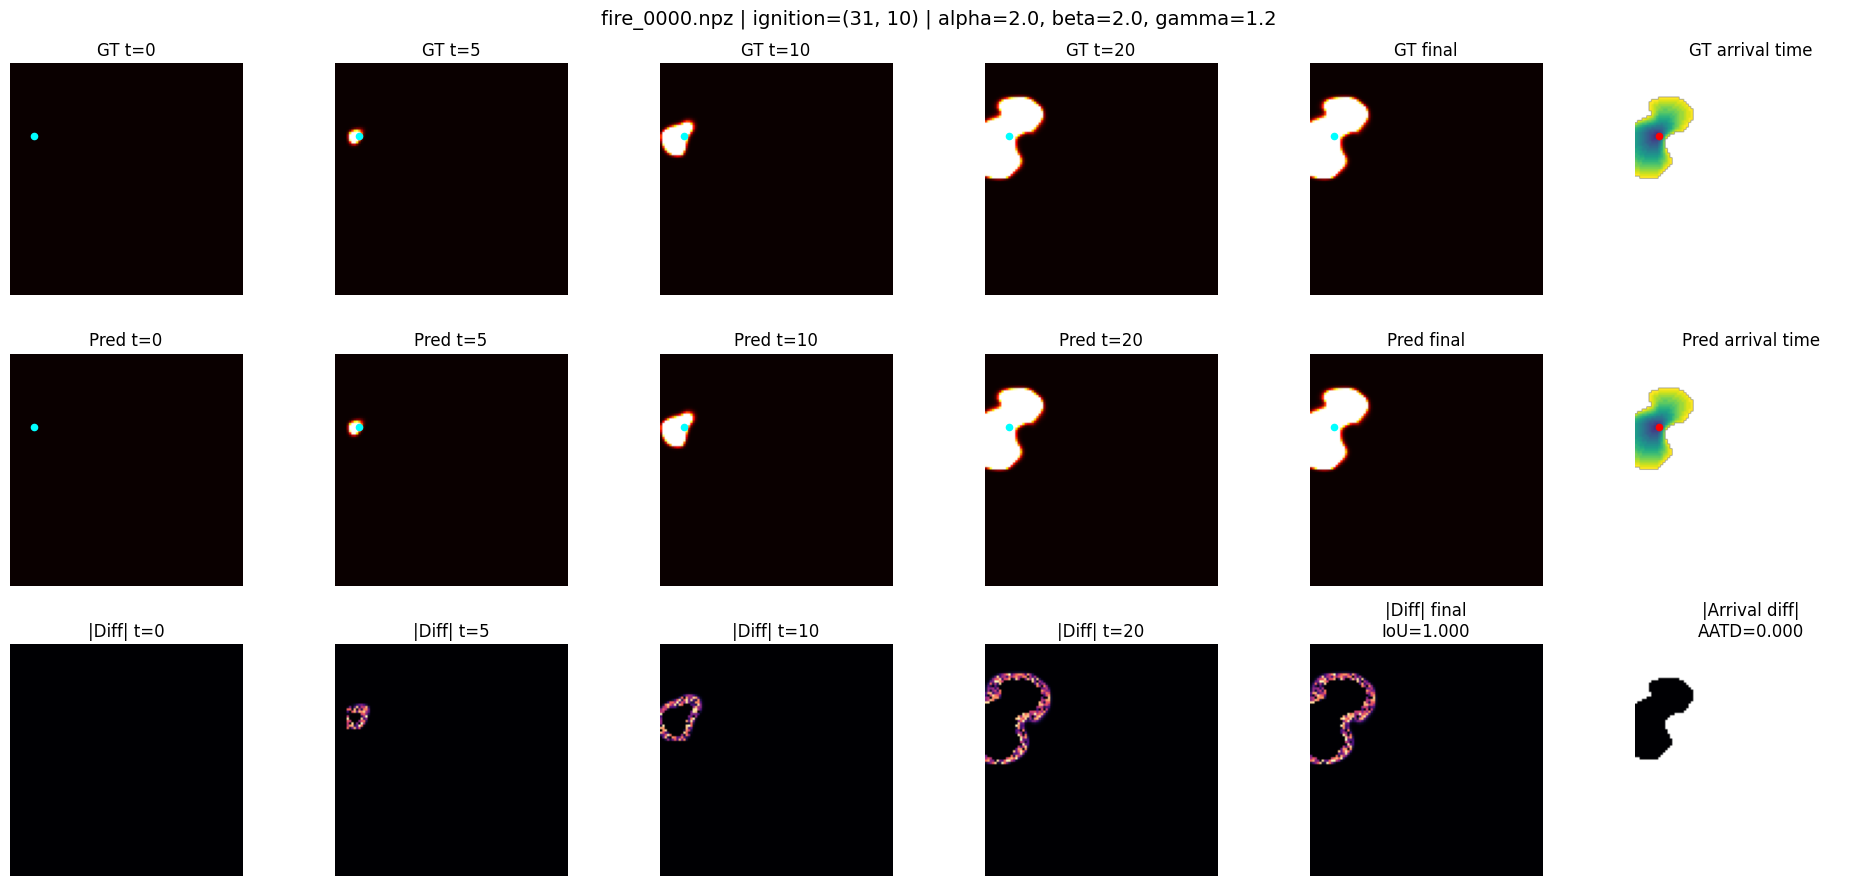

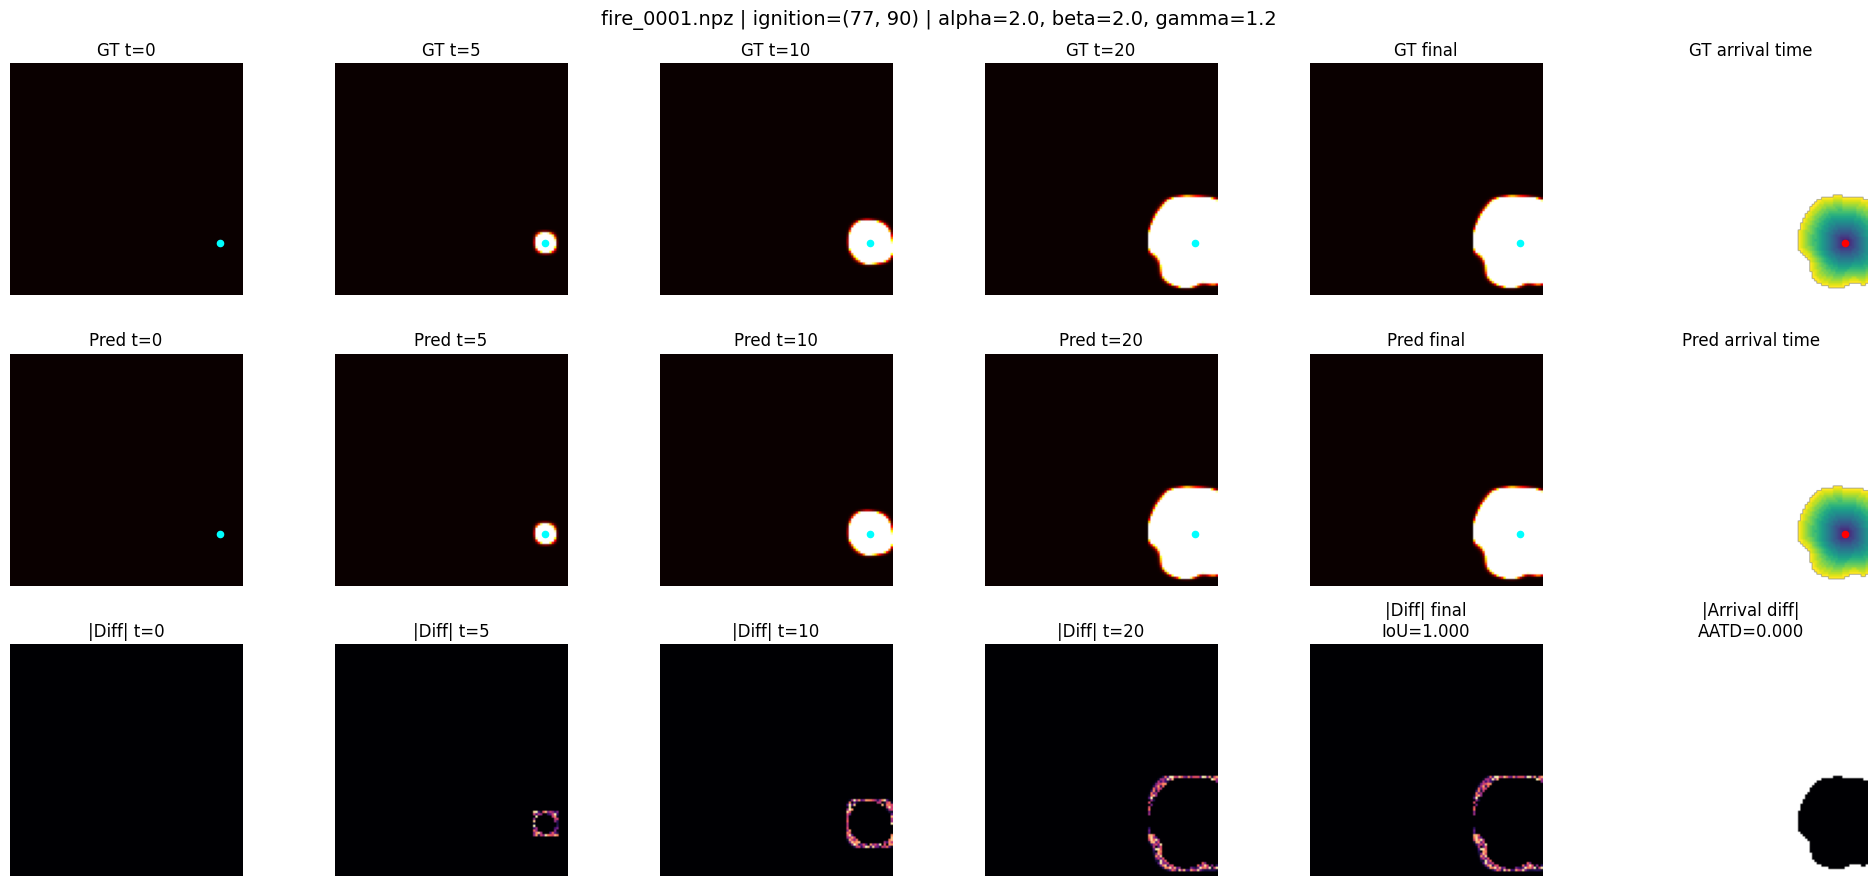

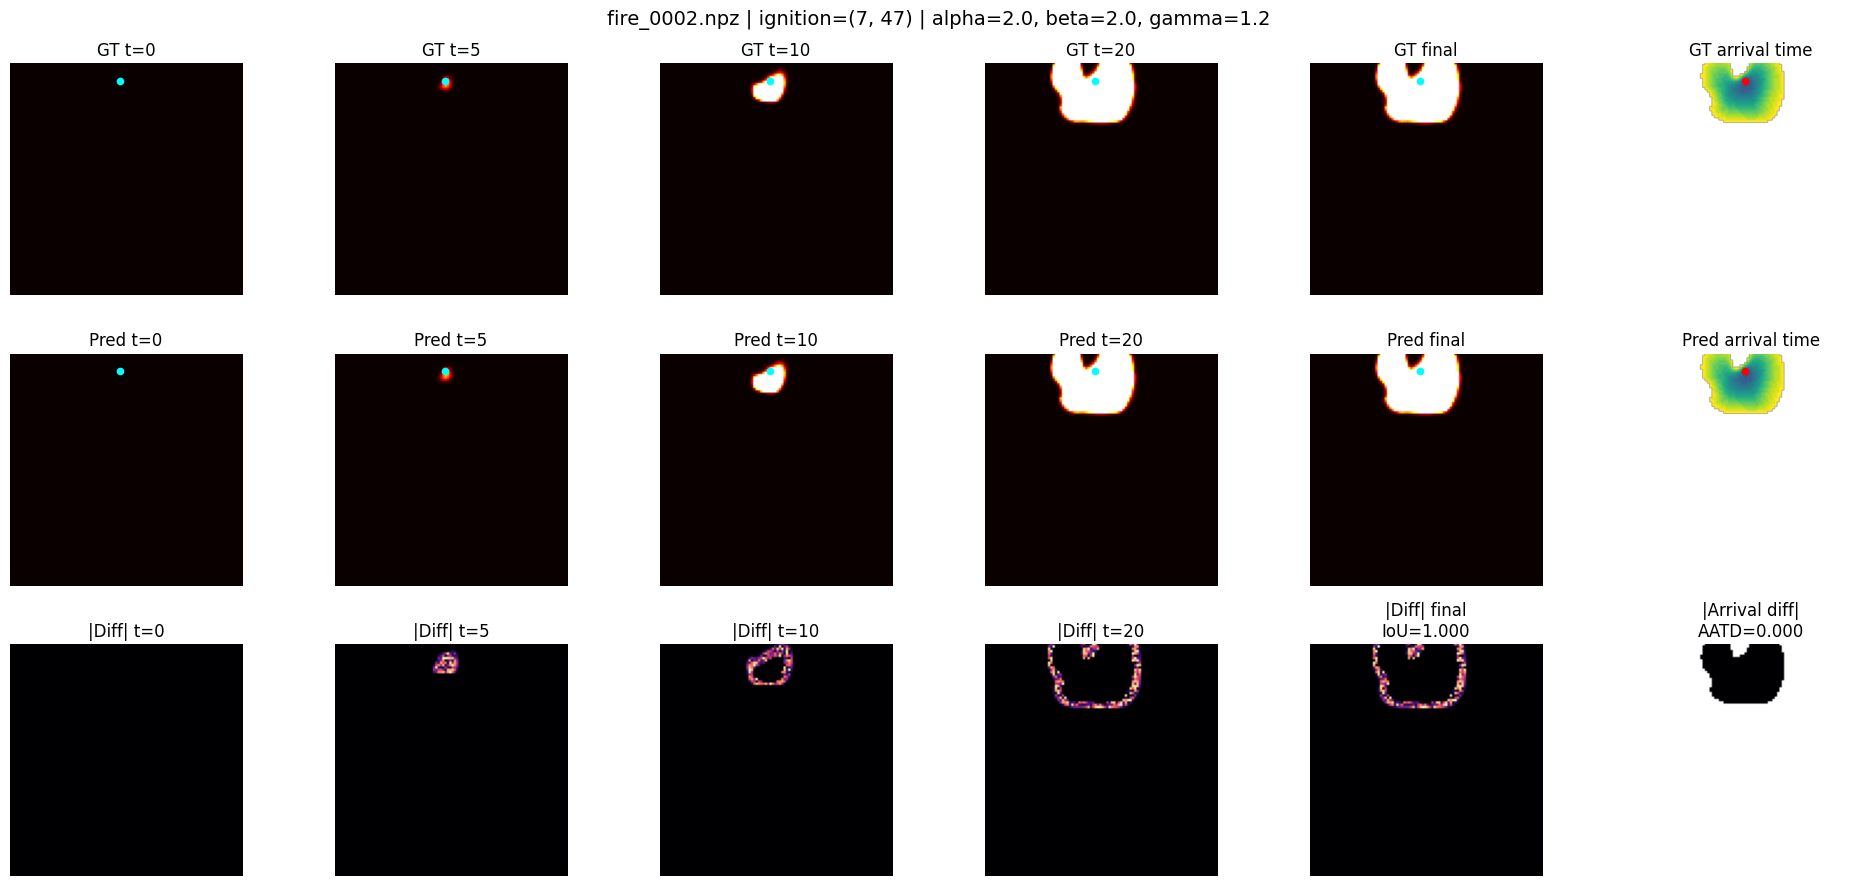

In [67]:
# Choix du meilleur triplet
if "mean_aatd" in results_df.columns and results_df["mean_aatd"].notna().any():
    df_valid = results_df.dropna(subset=["mean_aatd"]).copy()
    best_alpha, best_beta, best_gamma, best_row = get_best_params(
        df_valid,
        criterion="mean_aatd"
    )
    print("Best parameters according to AATD:")
    print(best_row[["alpha", "beta", "gamma", "mean_iou", "mean_aatd"]])
else:
    best_alpha, best_beta, best_gamma, best_row = get_best_params(
        results_df,
        criterion="mean_iou_loss"
    )
    print("Best parameters according to IoU:")
    cols = ["alpha", "beta", "gamma", "mean_iou"]
    if "mean_iou_loss" in best_row.index:
        cols.append("mean_iou_loss")
    print(best_row[cols])

# Nombre de feux à afficher
N_SHOW = min(3, len(fire_paths))

# Affichage
for fire_path in fire_paths[:N_SHOW]:
    plot_fire_comparison(
        fire_path=fire_path,
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        alpha=best_alpha,
        beta=best_beta,
        gamma=best_gamma,
        n_steps=N_STEPS,
    )